# Notebook 2: Exploratory analysis of the dataset (EDA)

This notebook focuses on performing an Exploratory Data Analysis (EDA) on the Developer Survey Dataset. EDA is a crucial step in the data analysis process as it helps us understand the structure and characteristics of the dataset. By analyzing this dataset, we can uncover patterns, relationships, and potential insights that will guide further analysis, data cleaning, and decision-making. In this notebook, we will explore the dataset using various statistical and visualization techniques.

### Structure of the Notebook
- Setup: Import libraries and establish a database connection.
- Data Loading: Load the dataset from the `raw_survey` table.
- Dataset Overview: Examine the structure, data types, and basic statistics.
- Column Analysis: Focus on relevant columns, analyzing unique values and null counts.
- Distribution Analysis: Visualize distributions of key variables (enhancing existing visuals where possible).
- Relationship Analysis: Explore relationships between variables (preserving and improving your friend’s heatmap).
- Conclusions and Next Steps: Summarize findings and recommend transformations for data cleaning.

## Setup

We import necessary libraries for data manipulation and visualization, set up the plotting style, and establish a connection to the PostgreSQL database.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

load_dotenv()
DB_USER = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST = os.getenv('DB_HOST', 'localhost')
DB_PORT = os.getenv('DB_PORT', '5432')
DB_NAME = os.getenv('DB_NAME', 'dev_survey_insights')
DATABASE_URL = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)

## Load Data

We load the full dataset from the `raw_survey` table in the PostgreSQL database into a Pandas DataFrame for analysis.

In [24]:
query = "SELECT * FROM raw_survey"
df = pd.read_sql(query, engine)
print(f"Data loaded successfully. Rows: {len(df)}, Columns: {len(df.columns)}")

Data loaded successfully. Rows: 98855, Columns: 129


## Dataset Overview

We examine the dataset's structure, data types, and basic statistics to get an initial understanding.

In [25]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98855 entries, 0 to 98854
Columns: 129 entries, Respondent to SurveyEasy
dtypes: float64(41), int64(1), object(87)
memory usage: 97.3+ MB


,Respondent,AssessJob1,AssessJob2,AssessJob3,AssessJob4,AssessJob5,AssessJob6,AssessJob7,AssessJob8,AssessJob9,...,JobEmailPriorities6,JobEmailPriorities7,ConvertedSalary,AdsPriorities1,AdsPriorities2,AdsPriorities3,AdsPriorities4,AdsPriorities5,AdsPriorities6,AdsPriorities7
count,98855.000000,66985.000000,66985.000000,66985.000000,66985.000000,66985.000000,66985.000000,66985.000000,66985.000000,66985.000000,...,46213.00000,46213.000000,4.770200e+04,60479.000000,60479.000000,60479.000000,60479.000000,60479.000000,60479.000000,60479.000000
mean,50822.971635,6.397089,6.673524,5.906875,4.065791,3.953243,4.407196,5.673181,4.225200,7.640009,...,4.97425,4.836388,9.578086e+04,2.726880,3.805784,3.340945,3.782470,4.383604,5.138809,4.821459
std,29321.650410,2.788428,2.531202,2.642734,2.541196,2.520499,2.502069,2.923998,2.507411,2.407457,...,1.86063,1.659844,2.023482e+05,1.881078,1.821323,1.673485,1.844864,1.931746,1.853249,1.874895
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.00000,1.000000,0.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,25443.500000,4.000000,5.000000,4.000000,2.000000,2.000000,2.000000,3.000000,2.000000,6.000000,...,4.00000,4.000000,2.384400e+04,1.000000,2.000000,2.000000,2.000000,3.000000,4.000000,3.000000
50%,50823.000000,7.000000,7.000000,6.000000,4.000000,3.000000,4.000000,6.000000,4.000000,8.000000,...,5.00000,5.000000,5.507500e+04,2.000000,4.000000,3.000000,4.000000,5.000000,6.000000,5.000000
75%,76219.500000,9.000000,9.000000,8.000000,6.000000,6.000000,6.000000,8.000000,6.000000,10.000000,...,7.00000,6.000000,9.300000e+04,4.000000,5.000000,5.000000,5.000000,6.000000,7.000000,7.000000
max,101592.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,7.00000,7.000000,2.000000e+06,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000


## Column Analysis

We focus on a subset of relevant columns to analyze their unique values, null counts, and potential cleaning needs. These columns are grouped into categories for clarity.

In [26]:
print("Total number of columns:", len(df.columns))
print("Available columns:\n", df.columns.tolist())

Total number of columns: 129
Available columns:
 ['Respondent', 'Hobby', 'OpenSource', 'Country', 'Student', 'Employment', 'FormalEducation', 'UndergradMajor', 'CompanySize', 'DevType', 'YearsCoding', 'YearsCodingProf', 'JobSatisfaction', 'CareerSatisfaction', 'HopeFiveYears', 'JobSearchStatus', 'LastNewJob', 'AssessJob1', 'AssessJob2', 'AssessJob3', 'AssessJob4', 'AssessJob5', 'AssessJob6', 'AssessJob7', 'AssessJob8', 'AssessJob9', 'AssessJob10', 'AssessBenefits1', 'AssessBenefits2', 'AssessBenefits3', 'AssessBenefits4', 'AssessBenefits5', 'AssessBenefits6', 'AssessBenefits7', 'AssessBenefits8', 'AssessBenefits9', 'AssessBenefits10', 'AssessBenefits11', 'JobContactPriorities1', 'JobContactPriorities2', 'JobContactPriorities3', 'JobContactPriorities4', 'JobContactPriorities5', 'JobEmailPriorities1', 'JobEmailPriorities2', 'JobEmailPriorities3', 'JobEmailPriorities4', 'JobEmailPriorities5', 'JobEmailPriorities6', 'JobEmailPriorities7', 'UpdateCV', 'Currency', 'Salary', 'SalaryType', 'Co


### Keep Only the Relevant Columns
We define and select a subset of columns relevant to our analysis.

In [27]:
relevant_columns = [
    # Demographic
    'Country', 'Gender', 'Age', 'FormalEducation', 'RaceEthnicity',
    # Professional Experience
    'DevType', 'CompanySize', 'Employment', 'YearsCoding', 'YearsCodingProf',
    # Technologies and Tools
    'LanguageWorkedWith', 'LanguageDesireNextYear', 'DatabaseWorkedWith',
    'DatabaseDesireNextYear', 'PlatformWorkedWith', 'PlatformDesireNextYear',
    'FrameworkWorkedWith', 'FrameworkDesireNextYear', 'IDE', 'OperatingSystem',
    # Salary and Compensation
    'Salary', 'ConvertedSalary', 'SalaryType', 'CurrencySymbol',
    # Job Satisfaction
    'JobSatisfaction', 'CareerSatisfaction', 'HopeFiveYears',
    # Miscellaneous
    'OpenSource', 'StackOverflowVisit', 'StackOverflowHasAccount',
    'StackOverflowParticipate', 'AIDangerous', 'AIInteresting',
    'AIResponsible', 'AIFuture'
]

df_relevant = df[relevant_columns]
print("New DataFrame with relevant columns created. Shape:", df_relevant.shape)

New DataFrame with relevant columns created. Shape: (98855, 35)


Check for null values in relevant columns

In [28]:
print("Null counts for relevant columns:")
print(df_relevant.isnull().sum())

Null counts for relevant columns:
Country                       412
Gender                      34386
Age                         34281
FormalEducation              4152
RaceEthnicity               41382
DevType                      6757
CompanySize                 27324
Employment                   3534
YearsCoding                  5020
YearsCodingProf             20952
LanguageWorkedWith          20521
LanguageDesireNextYear      25611
DatabaseWorkedWith          32585
DatabaseDesireNextYear      41357
PlatformWorkedWith          32856
PlatformDesireNextYear      37502
FrameworkWorkedWith         47235
FrameworkDesireNextYear     43637
IDE                         23457
OperatingSystem             22676
Salary                      48277
ConvertedSalary             51153
SalaryType                  47785
CurrencySymbol              40205
JobSatisfaction             29579
CareerSatisfaction          22351
HopeFiveYears               23137
OpenSource                      0
StackOverflowV

Analyze unique values for key categorical columns

In [29]:
print("\nUnique values for categorical columns (sample):")
for col in ['Country', 'Gender', 'Age', 'FormalEducation', 'Employment']:
    unique_vals = df_relevant[col].unique()
    print(f"\n{col} ({len(unique_vals)} unique values):\n", unique_vals[:10])


Unique values for categorical columns (sample):

Country (184 unique values):
 ['United States' 'India' 'France' 'United Kingdom' 'Egypt' 'Germany'
 'Indonesia' 'Hong Kong (S.A.R.)' 'Turkey' 'Netherlands']

Gender (16 unique values):
 ['Male' None 'Female' 'Non-binary, genderqueer, or gender non-conforming'
 'Transgender' 'Female;Transgender' 'Female;Male'
 'Male;Non-binary, genderqueer, or gender non-conforming'
 'Transgender;Non-binary, genderqueer, or gender non-conforming'
 'Female;Non-binary, genderqueer, or gender non-conforming']

Age (8 unique values):
 ['25 - 34 years old' None '45 - 54 years old' '18 - 24 years old'
 '35 - 44 years old' '55 - 64 years old' 'Under 18 years old'
 '65 years or older']

FormalEducation (10 unique values):
 ['Associate degree'
 'Some college/university study without earning a degree' None
 'Bachelor’s degree (BA, BS, B.Eng., etc.)'
 'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)'
 'Professional degree (JD, MD,

## Distribution Analysis

### Geographic Distribution

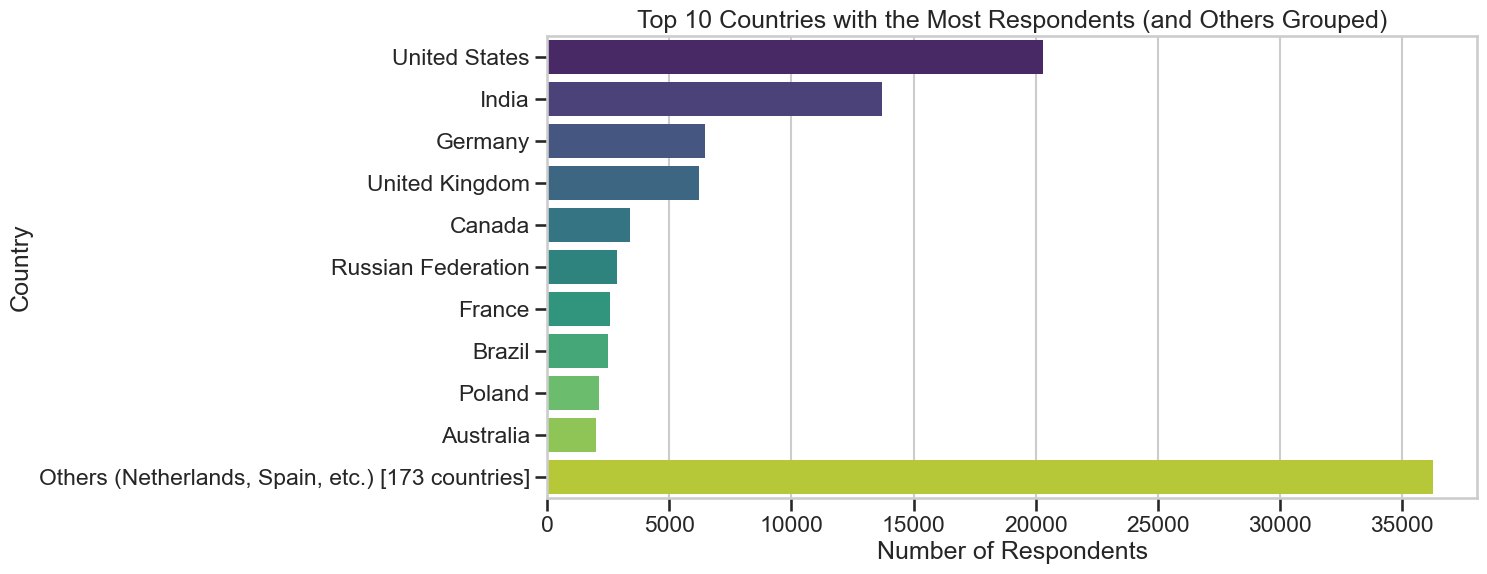

In [30]:
country_counts = df["Country"].value_counts()
top_10_countries = country_counts.head(10)
rest_countries = country_counts.iloc[10:]
sum_rest = rest_countries.sum()
others_count = len(rest_countries)

some_others = rest_countries.index[:2]
some_others_str = ", ".join(some_others) + ", etc."
other_label = f"Others ({some_others_str}) [{others_count} countries]"

top_10_countries = pd.concat([top_10_countries, pd.Series({other_label: sum_rest})])

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_countries.values, y=top_10_countries.index, palette="viridis")
plt.title("Top 10 Countries with the Most Respondents (and Others Grouped)")
plt.xlabel("Number of Respondents")
plt.ylabel("Country")
plt.show()

### Gender Distribution

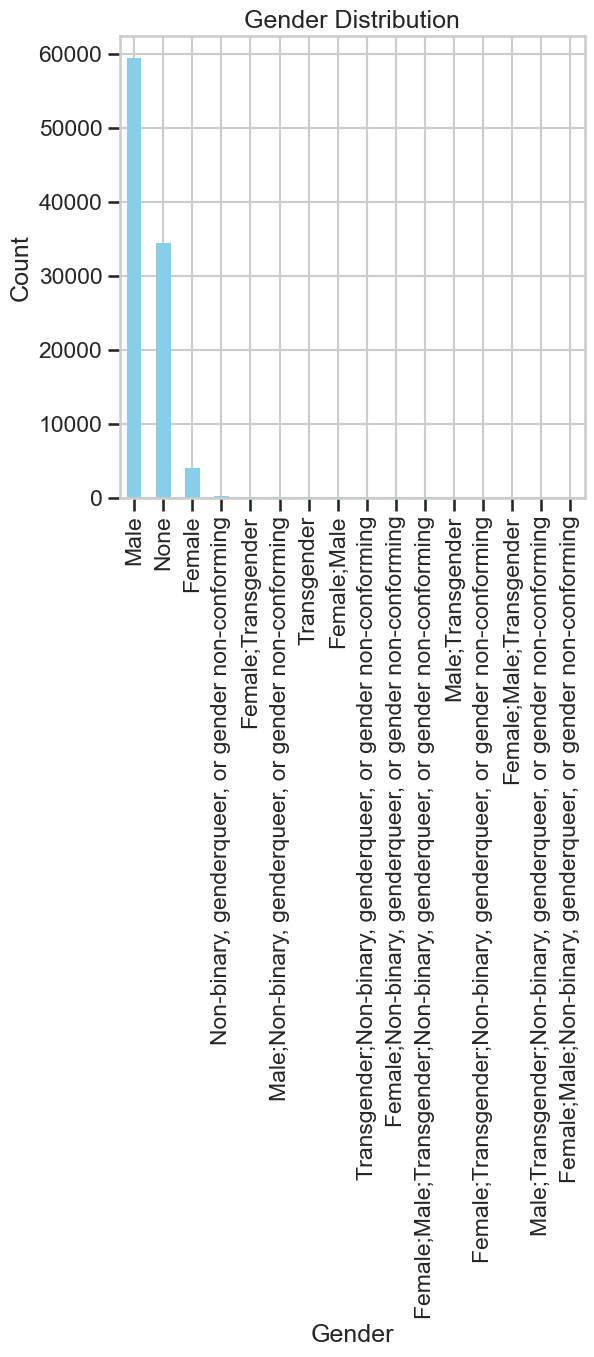

In [31]:
plt.figure(figsize=(6, 6))
gender_counts = df["Gender"].value_counts(dropna=False)
gender_counts.plot(kind="bar", color="skyblue")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

### Age Distribution

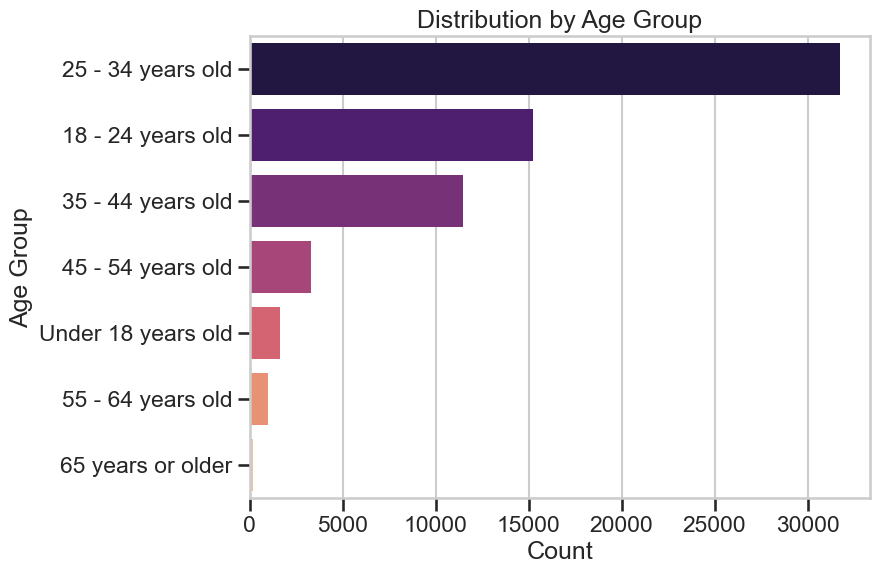

In [32]:
plt.figure(figsize=(8, 6))
age_counts = df["Age"].value_counts()
sns.barplot(x=age_counts.values, y=age_counts.index, palette="magma")
plt.title("Distribution by Age Group")
plt.xlabel("Count")
plt.ylabel("Age Group")
plt.show()

### Formal Education Level

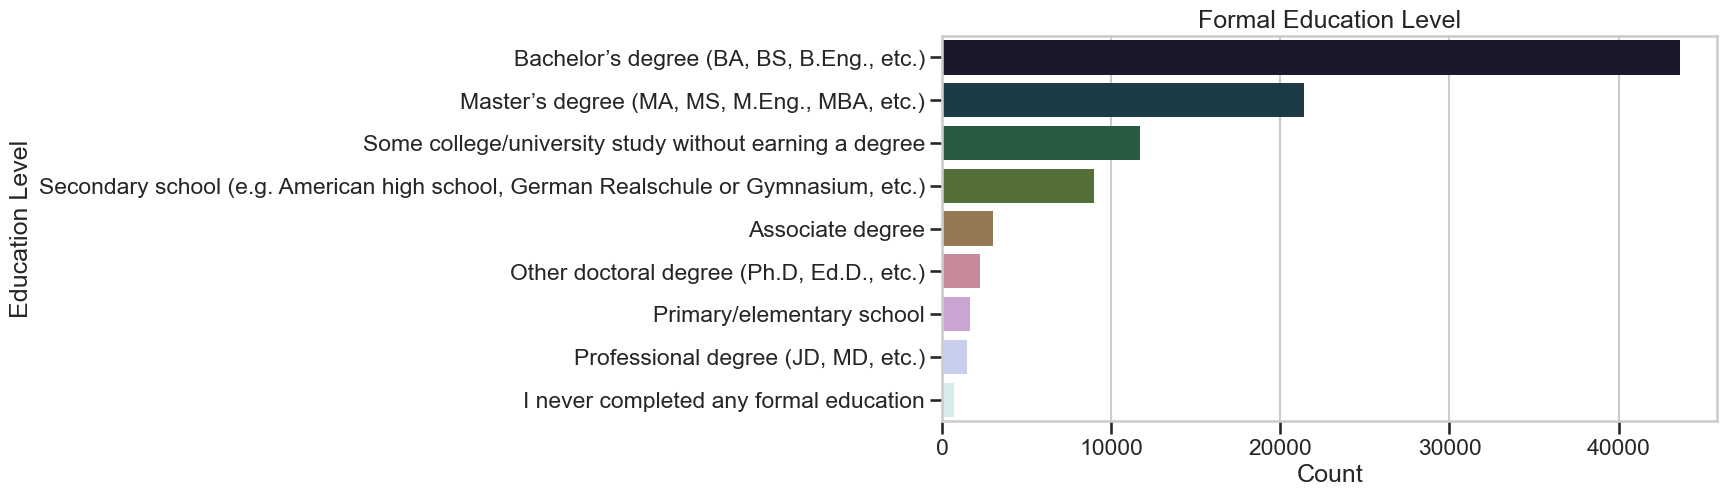

In [33]:
plt.figure(figsize=(10, 5))
edu_counts = df["FormalEducation"].value_counts()
sns.barplot(x=edu_counts.values, y=edu_counts.index, palette="cubehelix")
plt.title("Formal Education Level")
plt.xlabel("Count")
plt.ylabel("Education Level")
plt.show()

### Developer Types (DevType)

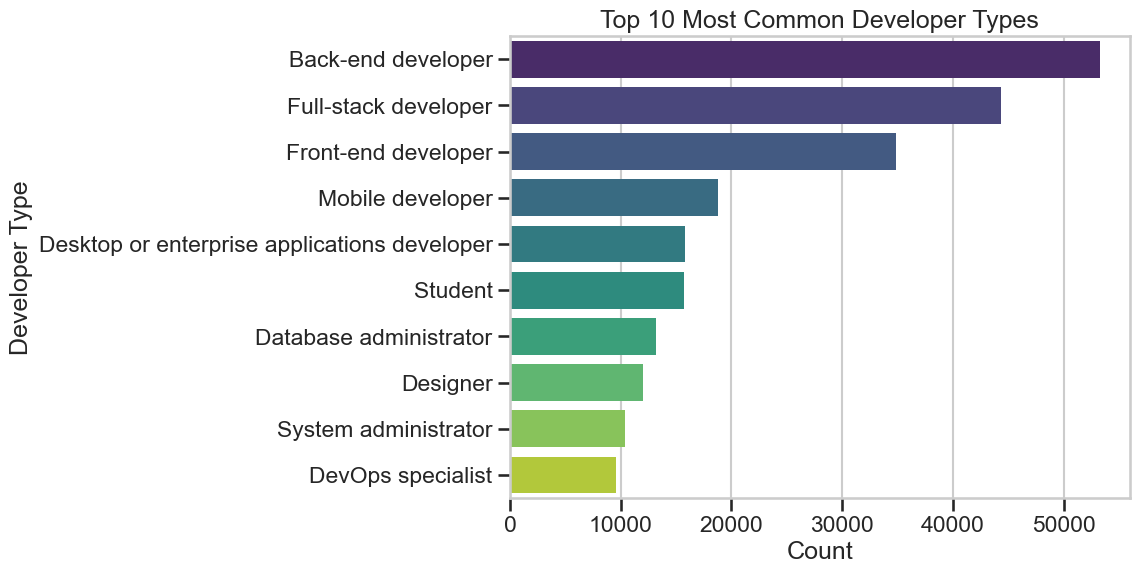

In [34]:
df_devtype = df["DevType"].dropna().str.split(";", expand=True).stack().reset_index(drop=True)
top_devtype = df_devtype.value_counts().head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_devtype.values, y=top_devtype.index, palette="viridis")
plt.title("Top 10 Most Common Developer Types")
plt.xlabel("Count")
plt.ylabel("Developer Type")
plt.show()

### Years Coding

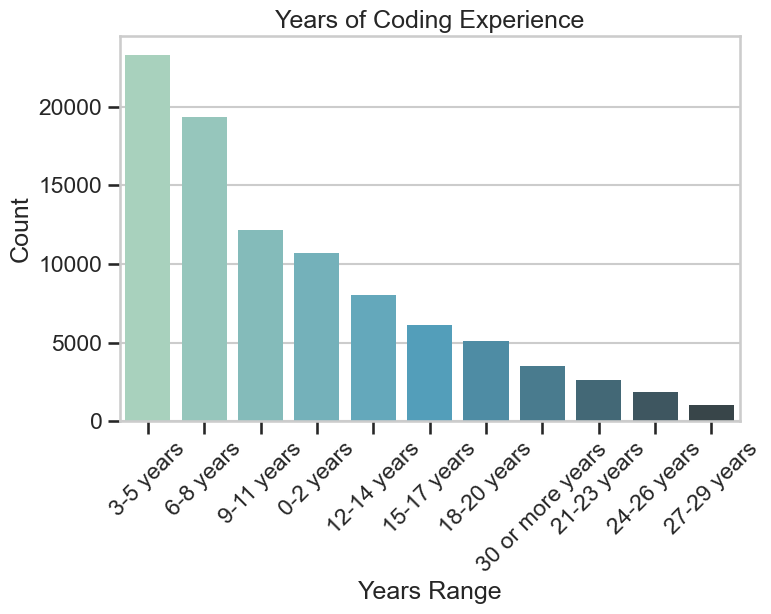

In [35]:
plt.figure(figsize=(8, 5))
yc_counts = df["YearsCoding"].value_counts()
sns.barplot(x=yc_counts.index, y=yc_counts.values, palette="GnBu_d")
plt.title("Years of Coding Experience")
plt.xlabel("Years Range")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Employment Status


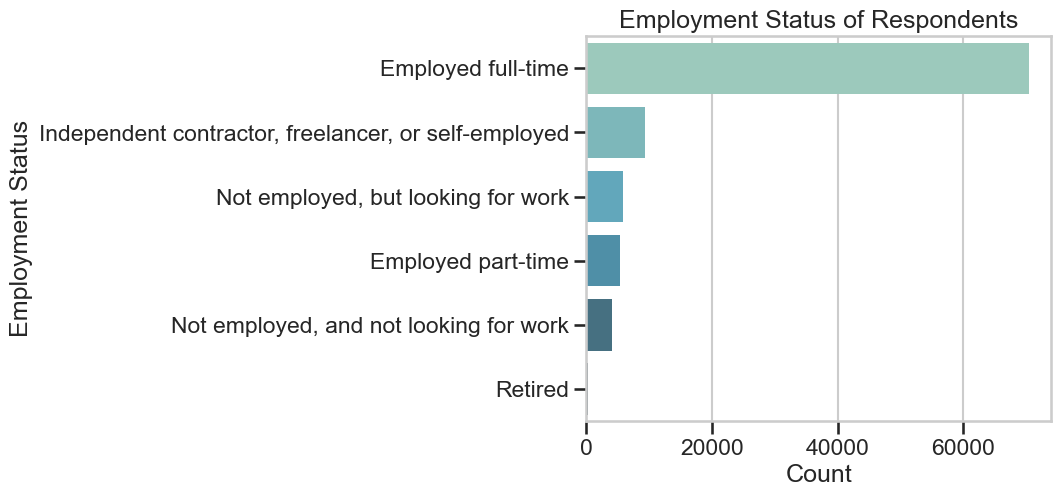

In [36]:
plt.figure(figsize=(6, 5))
employment_counts = df["Employment"].value_counts()
sns.barplot(y=employment_counts.index, x=employment_counts.values, palette="GnBu_d")
plt.title("Employment Status of Respondents")
plt.xlabel("Count")
plt.ylabel("Employment Status")
plt.show()

## Technologies and Tools

### Languages Worked With

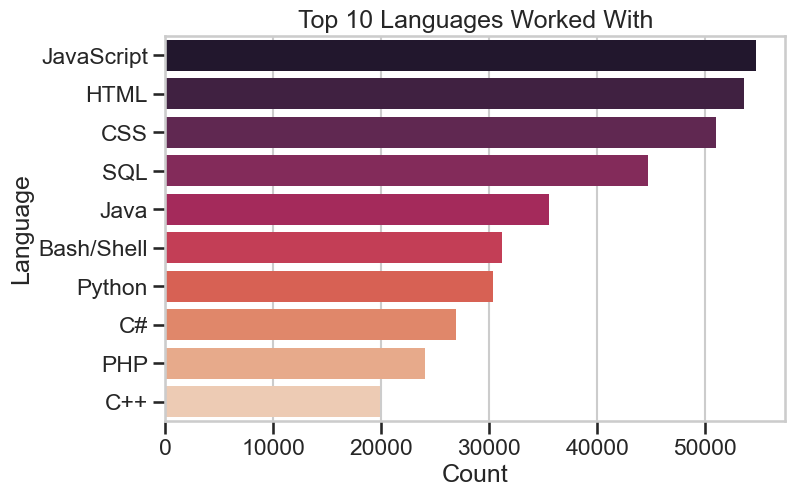

In [37]:
df_lang = df["LanguageWorkedWith"].dropna().str.split(";", expand=True).stack().reset_index(drop=True)
top_lang = df_lang.value_counts().head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_lang.values, y=top_lang.index, palette="rocket")
plt.title("Top 10 Languages Worked With")
plt.xlabel("Count")
plt.ylabel("Language")
plt.show()

### Languages Desired Next Year

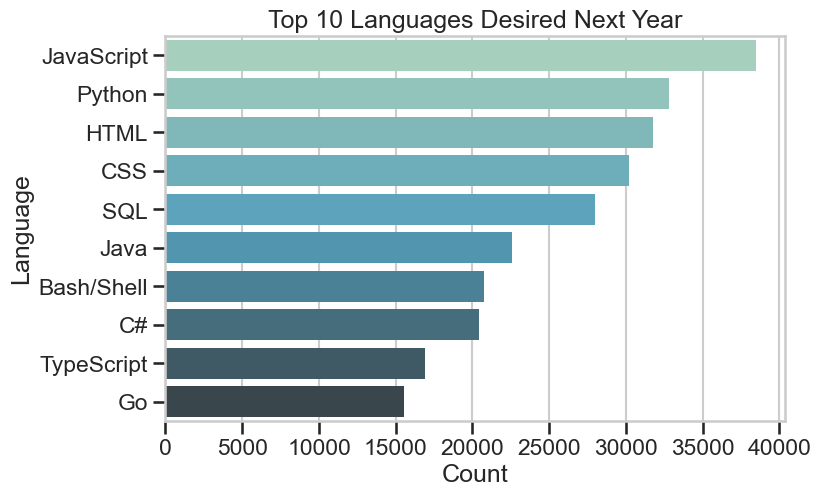

In [38]:
df_lang_desired = df["LanguageDesireNextYear"].dropna().str.split(";", expand=True).stack().reset_index(drop=True)
top_lang_desired = df_lang_desired.value_counts().head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_lang_desired.values, y=top_lang_desired.index, palette="GnBu_d")
plt.title("Top 10 Languages Desired Next Year")
plt.xlabel("Count")
plt.ylabel("Language")
plt.show()

## Salary Analysis

### Distribution of Converted Salary

c:\College\ETL\Proyecto\DevSurveyInsights\venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


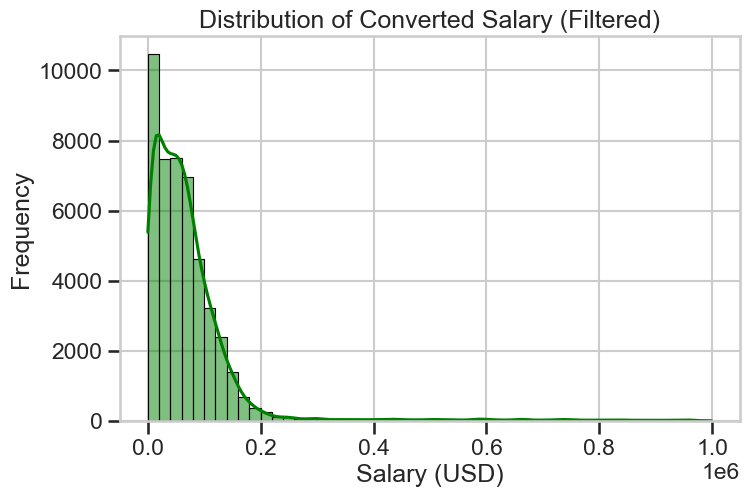

In [39]:
df_salary = df["ConvertedSalary"].dropna()
salary_99th = df_salary.quantile(0.99)
df_salary_filtered = df_salary[df_salary < salary_99th]

plt.figure(figsize=(8, 5))
sns.histplot(df_salary_filtered, kde=True, color="green", bins=50)
plt.title("Distribution of Converted Salary (Filtered)")
plt.xlabel("Salary (USD)")
plt.ylabel("Frequency")
plt.show()

### Salary Comparison by Country (Top 5)

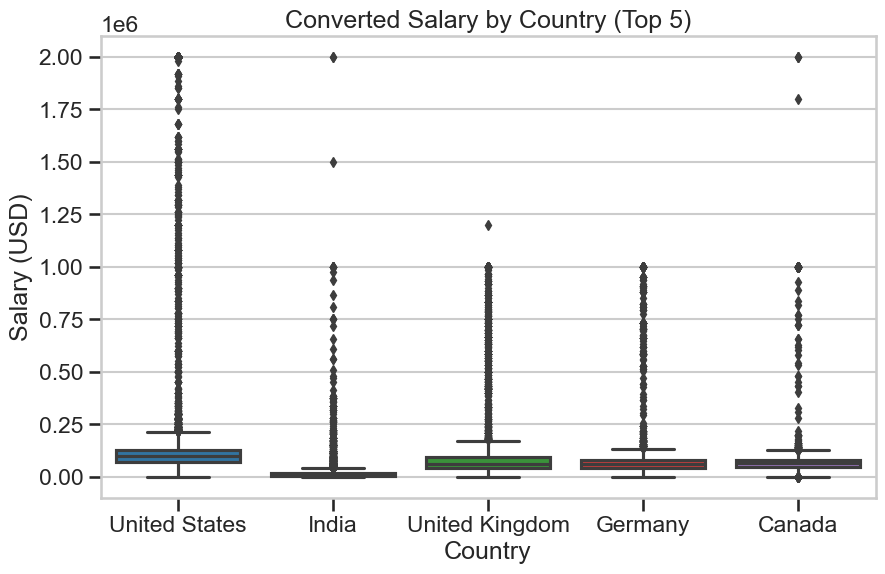

In [40]:
top_countries = df["Country"].value_counts().head(5).index
df_top_countries = df[df["Country"].isin(top_countries)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_top_countries, x="Country", y="ConvertedSalary")
plt.title("Converted Salary by Country (Top 5)")
plt.xlabel("Country")
plt.ylabel("Salary (USD)")
plt.show()

## Job Satisfaction Analysis

### Job Satisfaction

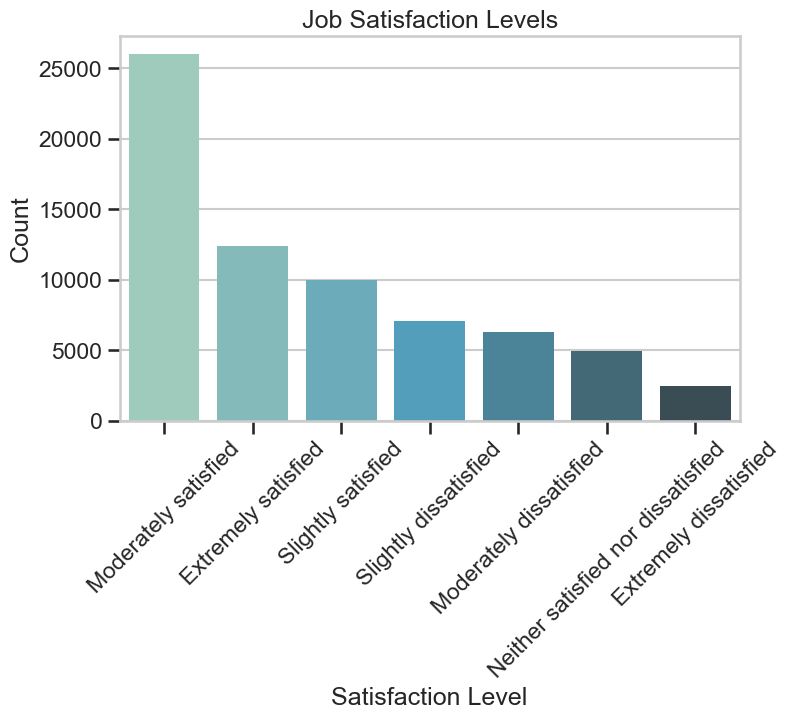

In [41]:
plt.figure(figsize=(8, 5))
job_sat_counts = df["JobSatisfaction"].value_counts()
sns.barplot(x=job_sat_counts.index, y=job_sat_counts.values, palette="GnBu_d")
plt.title("Job Satisfaction Levels")
plt.xlabel("Satisfaction Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Career Satisfaction

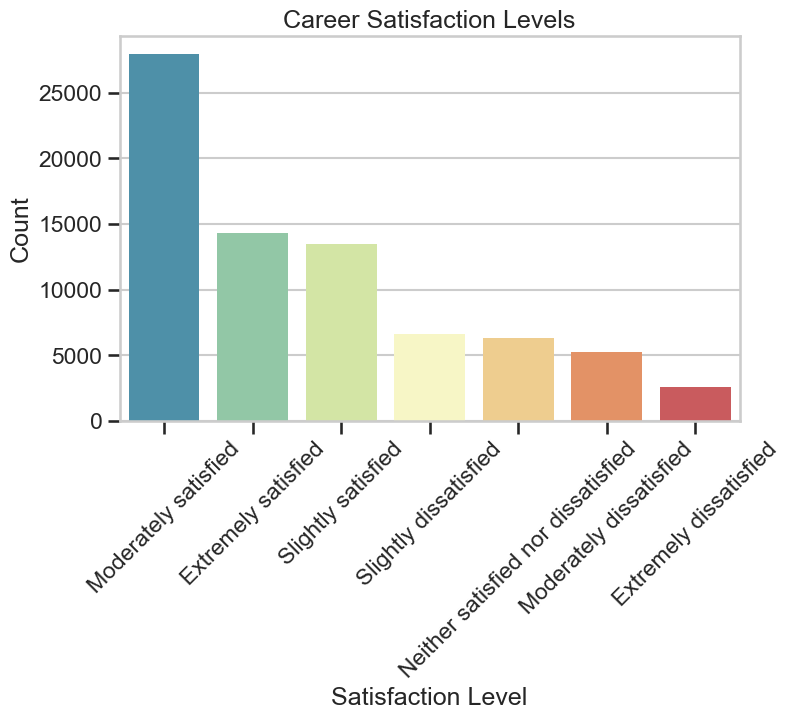

In [42]:
plt.figure(figsize=(8, 5))
career_sat_counts = df["CareerSatisfaction"].value_counts()
sns.barplot(x=career_sat_counts.index, y=career_sat_counts.values, palette="Spectral_r")
plt.title("Career Satisfaction Levels")
plt.xlabel("Satisfaction Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Relationship Analysis

### Heatmap: Top 5 Developer Types vs. Top 5 Languages

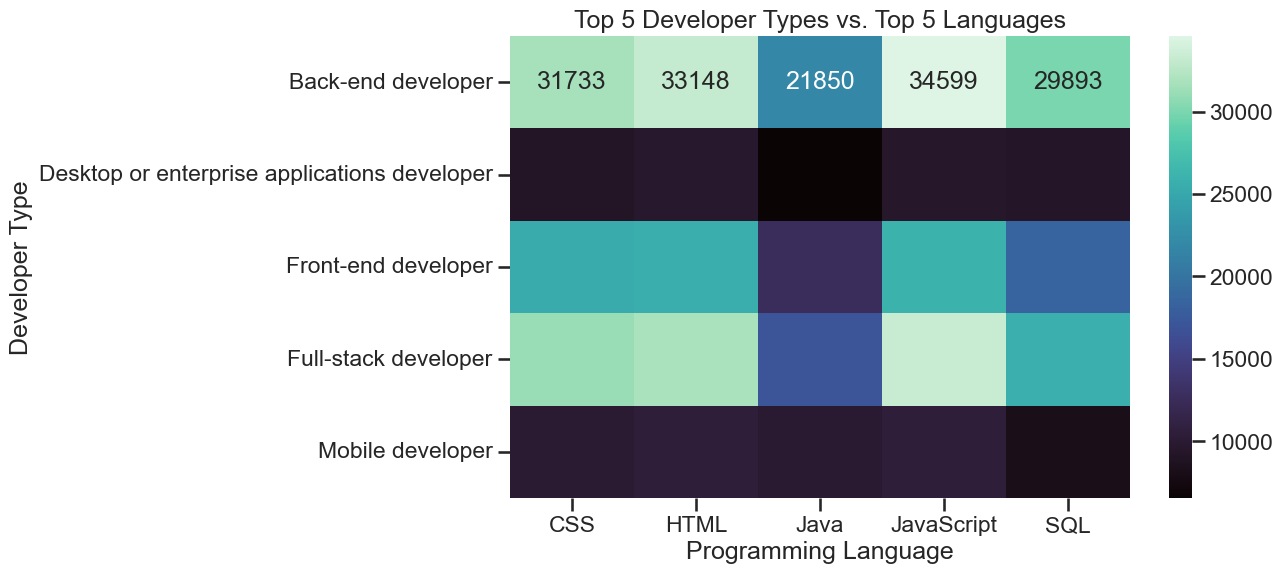

In [43]:
dev_lang_df = df_relevant[['DevType', 'LanguageWorkedWith']].dropna()
dev_lang_df = dev_lang_df.assign(
    DevType=dev_lang_df['DevType'].str.split(';'),
    LanguageWorkedWith=dev_lang_df['LanguageWorkedWith'].str.split(';')
).explode('DevType').explode('LanguageWorkedWith')

top_5_dev = dev_lang_df['DevType'].value_counts().head(5).index
top_5_lang = dev_lang_df['LanguageWorkedWith'].value_counts().head(5).index
filtered_df = dev_lang_df[dev_lang_df['DevType'].isin(top_5_dev) & dev_lang_df['LanguageWorkedWith'].isin(top_5_lang)]

pivot_df = filtered_df.pivot_table(index='DevType', columns='LanguageWorkedWith', aggfunc='size', fill_value=0)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, fmt='d', cmap='mako')
plt.title('Top 5 Developer Types vs. Top 5 Languages')
plt.xlabel('Programming Language')
plt.ylabel('Developer Type')
plt.show()

# Conclusiones


**Geographic Distribution:**  
The majority of respondents come from large countries such as the United States, United Kingdom, Germany, Canada, India, etc. It is observed that "Others" (the rest of the countries) also represent a significant portion, indicating that there is considerable geographic diversity, although it is concentrated in the main technological hubs.

**Gender:**  
There is a higher number of respondents identifying as male. Other categories, for example, Female, NA, or others, have lower representation, which confirms the gender bias that typically exists in the technology industry.

**Age:**  
The age range of 25 - 34 is the most represented, followed by "18 - 24." This aligns with a young profile of the developer population.

**Technologies:**  
Languages such as JavaScript, Python, or Java (depending on the survey) usually appear in the top 10 most used. This indicates that they are popular and widely used. Similarly, well-known frameworks and platforms dominate the landscape (e.g., React, Angular, .NET, etc.).

**Salaries:**  
There is a great variability in salaries. In countries with higher purchasing power (for example, the United States), the median salary is higher than in other regions. When filtering out extreme values, a clearer distribution is obtained, with the majority of salaries falling below 100k-150k USD annually.

**Job Satisfaction:**  
A good percentage of developers report being satisfied or very satisfied with their work and career. However, there is always a fraction that expresses dissatisfaction, which may be related to factors such as stress, salary, or lack of growth.